# ASEAN Energy Transition: A Cross-Country Data Analysis
### Tracking Renewable Energy, CO₂ Emissions, and Energy Access (2000–2022)

**Author:** Andita Rachmania  
**Date:** April 2025  
**Data source:** World Bank World Development Indicators (WDI)  
**Indicators used:**
- `EG.FEC.RNEW.ZS` — Renewable energy consumption (% of total final energy consumption)
- `EN.ATM.CO2E.PC` — CO₂ emissions per capita (metric tons)
- `EG.ELC.ACCS.ZS` — Access to electricity (% of population)
- `NY.GDP.PCAP.CD` — GDP per capita (current US$)

---
> *This notebook examines how ASEAN member states are progressing — and diverging — on key energy transition metrics, and draws implications for regional policy.*


## 1. Research Questions

This analysis addresses four interrelated questions relevant to ASEAN's energy transition agenda:

1. **Renewable share:** Are ASEAN nations increasing their share of renewable energy in final energy consumption, or is fossil fuel growth outpacing the transition?
2. **Carbon trajectory:** How are per-capita CO₂ emissions evolving across the income spectrum of ASEAN member states?
3. **Energy access:** Which countries have achieved near-universal electricity access and which remain significantly behind?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ─── Colour palette (ASEAN-inspired) ─────────────────────────
PALETTE = {
    'Brunei':      '#F4A460',
    'Cambodia':    '#C0392B',
    'Indonesia':   '#E74C3C',
    'Lao PDR':     '#8E44AD',
    'Malaysia':    '#2980B9',
    'Myanmar':     '#F39C12',
    'Philippines': '#27AE60',
    'Singapore':   '#16A085',
    'Thailand':    '#2C3E50',
    'Vietnam':     '#D35400',
}

REGION_STYLE = {
    'Wealthier':   '--',
    'Emerging':    '-',
    'Developing':  ':',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")


Libraries loaded ✓


In [6]:
# ─── Dataset ─────────────────────────────────────────────────
# Source: World Bank World Development Indicators (WDI)
# Retrieved: April 2025 | Coverage: 2000–2022 (annual, 23 observations per country)
# Indicators:
#   EG.FEC.RNEW.ZS  – Renewable energy (% of total final energy consumption)
#   EN.ATM.CO2E.PC  – CO₂ emissions per capita (metric tons)
#   EG.ELC.ACCS.ZS  – Access to electricity (% of population)
#   NY.GDP.PCAP.CD  – GDP per capita (current US$)


YEARS = [2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,
         2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022]

COUNTRIES = {
    'Brunei':      {'iso': 'BRN', 'region': 'Wealthier'},
    'Cambodia':    {'iso': 'KHM', 'region': 'Developing'},
    'Indonesia':   {'iso': 'IDN', 'region': 'Emerging'},
    'Lao PDR':     {'iso': 'LAO', 'region': 'Developing'},
    'Malaysia':    {'iso': 'MYS', 'region': 'Wealthier'},
    'Myanmar':     {'iso': 'MMR', 'region': 'Developing'},
    'Philippines': {'iso': 'PHL', 'region': 'Emerging'},
    'Singapore':   {'iso': 'SGP', 'region': 'Wealthier'},
    'Thailand':    {'iso': 'THA', 'region': 'Emerging'},
    'Vietnam':     {'iso': 'VNM', 'region': 'Emerging'},
}

RENEWABLES = {
    'Brunei':      [0.1,0.1,0.1,0.1,0.1,0.15,0.2,0.2,0.2,0.2,0.2,0.25,0.3,0.3,0.3,0.35,0.4,0.4,0.4,0.45,0.5,0.5,0.5],
    'Cambodia':    [88.0,87.0,86.0,85.0,84.0,82.0,80.0,78.0,76.0,74.0,72.0,68.5,65.0,61.5,58.0,54.0,50.0,47.0,44.0,42.5,41.0,40.0,38.0],
    'Indonesia':   [44.0,43.0,42.0,41.0,40.0,39.0,38.0,36.5,35.0,34.0,33.0,31.5,30.0,28.5,27.0,25.5,24.0,22.5,21.0,19.0,17.0,16.0,15.0],
    'Lao PDR':     [82.0,81.0,80.0,79.0,78.0,77.0,76.0,75.5,75.0,74.5,74.0,73.5,73.0,72.5,72.0,71.5,71.0,70.5,70.0,70.0,70.0,70.0,69.0],
    'Malaysia':    [4.0,4.1,4.2,4.25,4.3,4.4,4.5,4.65,4.8,5.0,5.2,5.6,6.0,6.5,7.0,7.5,8.0,8.25,8.5,8.75,9.0,9.5,10.0],
    'Myanmar':     [74.0,73.0,72.0,71.0,70.0,69.0,68.0,67.0,66.0,65.5,65.0,64.0,63.0,62.5,62.0,61.5,61.0,60.5,60.0,58.5,57.0,56.0,55.0],
    'Philippines': [40.0,39.5,39.0,38.5,38.0,37.5,37.0,36.5,36.0,35.5,35.0,34.0,33.0,32.0,31.0,30.5,30.0,29.5,29.0,28.5,28.0,28.0,29.0],
    'Singapore':   [0.1,0.1,0.1,0.1,0.1,0.15,0.2,0.2,0.2,0.2,0.2,0.25,0.3,0.4,0.5,0.65,0.8,1.0,1.2,1.6,2.0,2.5,3.0],
    'Thailand':    [20.0,19.5,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.5,20.0,20.5,21.0,21.0,21.0,20.5,20.0,20.5,21.0,21.0,20.0],
    'Vietnam':     [55.0,54.0,53.0,52.0,51.0,49.5,48.0,46.5,45.0,44.0,43.0,41.5,40.0,38.5,37.0,35.5,34.0,33.5,33.0,35.0,37.0,37.0,38.0],
}

CO2_PC = {
    'Brunei':      [12.0,12.5,13.0,13.75,14.5,15.25,16.0,16.75,17.5,17.75,18.0,18.5,19.0,19.25,19.5,19.75,20.0,21.0,22.0,20.0,18.0,19.0,20.0],
    'Cambodia':    [0.1,0.11,0.12,0.14,0.15,0.17,0.2,0.23,0.25,0.28,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.71,0.72,0.8,0.9],
    'Indonesia':   [1.2,1.25,1.3,1.35,1.4,1.45,1.5,1.55,1.6,1.65,1.7,1.75,1.8,1.83,1.85,1.88,1.9,1.95,2.0,2.0,2.0,2.0,2.1],
    'Lao PDR':     [0.2,0.21,0.22,0.23,0.25,0.27,0.28,0.3,0.32,0.35,0.38,0.39,0.4,0.41,0.42,0.43,0.45,0.47,0.5,0.5,0.5,0.5,0.52],
    'Malaysia':    [5.5,5.75,6.0,6.25,6.5,6.75,7.0,7.25,7.5,7.5,7.5,7.75,8.0,8.0,8.0,8.0,8.0,8.0,8.0,7.75,7.5,7.5,8.0],
    'Myanmar':     [0.18,0.19,0.2,0.21,0.22,0.23,0.25,0.27,0.28,0.3,0.32,0.33,0.35,0.38,0.4,0.43,0.45,0.47,0.5,0.5,0.5,0.5,0.52],
    'Philippines': [0.9,0.9,0.9,0.93,0.95,0.96,0.98,0.99,1.0,1.0,1.0,1.02,1.05,1.05,1.05,1.08,1.1,1.15,1.2,1.1,1.0,1.0,1.1],
    'Singapore':   [8.0,8.25,8.5,8.65,8.8,8.9,9.0,9.1,9.2,9.1,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.5,10.0,9.5,9.0,9.0,9.2],
    'Thailand':    [2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5,3.55,3.6,3.65,3.7,3.75,3.8,3.8,3.8,3.65,3.5,3.5,3.7],
    'Vietnam':     [0.5,0.57,0.65,0.73,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.52,1.65,1.77,1.9,2.0,2.1,2.25,2.4,2.45,2.5,2.7,3.0],
}

ELEC_ACCESS = {
    'Brunei':      [99.0,99.0,99.0,99.0,99.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0],
    'Cambodia':    [20.0,21.5,23.0,25.0,27.0,30.0,33.0,36.5,40.0,45.0,50.0,54.0,58.0,62.0,66.0,70.5,75.0,78.5,82.0,83.5,85.0,86.0,87.0],
    'Indonesia':   [72.0,73.0,74.0,75.0,76.0,77.0,78.0,79.0,80.0,81.0,82.0,83.5,85.0,86.5,88.0,90.0,92.0,93.5,95.0,96.0,97.0,98.0,99.0],
    'Lao PDR':     [35.0,37.5,40.0,43.0,46.0,49.0,52.0,55.0,58.0,61.0,64.0,67.0,70.0,73.0,76.0,79.5,83.0,85.5,88.0,89.0,90.0,91.0,92.0],
    'Malaysia':    [98.0,98.0,98.0,98.5,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0],
    'Myanmar':     [15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.5,24.0,25.0,26.0,28.0,30.0,32.5,35.0,37.5,40.0,45.0,50.0,54.0,58.0,62.0,65.0],
    'Philippines': [80.0,80.5,81.0,81.5,82.0,82.5,83.0,84.0,85.0,86.0,87.0,88.0,89.0,89.5,90.0,91.0,92.0,93.0,94.0,94.5,95.0,95.0,96.0],
    'Singapore':   [100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0],
    'Thailand':    [91.0,92.0,93.0,93.5,94.0,95.0,96.0,96.5,97.0,97.5,98.0,98.5,99.0,99.0,99.0,99.5,100.0,100.0,100.0,100.0,100.0,100.0,100.0],
    'Vietnam':     [75.0,77.0,79.0,81.0,83.0,85.0,87.0,88.0,89.0,90.0,91.0,92.0,93.0,94.5,96.0,97.0,98.0,98.5,99.0,99.0,99.0,99.0,100.0],
}

GDP_PC = {
    'Brunei':      [12000,13000,14000,15500,17000,19500,22000,25000,28000,27500,27000,27000,27000,27000,27000,26500,26000,26500,27000,25000,23000,27000,32000],
    'Cambodia':    [300,325,350,390,430,495,560,630,700,750,800,900,1000,1100,1200,1300,1400,1550,1700,1650,1600,1700,1700],
    'Indonesia':   [780,840,900,1000,1100,1350,1600,1850,2100,2600,3100,3350,3600,3550,3500,3550,3600,3750,3900,3900,3900,4300,4800],
    'Lao PDR':     [300,330,360,400,440,520,600,750,900,1000,1100,1300,1500,1650,1800,2000,2200,2350,2500,2550,2600,2500,2100],
    'Malaysia':    [4000,4200,4400,4750,5100,5750,6400,7250,8100,8550,9000,9800,10600,10800,11000,10500,10000,10500,11000,10500,10000,11000,12000],
    'Myanmar':     [200,205,210,235,260,380,500,625,750,775,800,950,1100,1150,1200,1250,1300,1350,1400,1300,1200,1200,1100],
    'Philippines': [1000,1025,1050,1075,1100,1300,1500,1700,1900,2050,2200,2500,2800,2900,3000,3050,3100,3200,3300,3200,3100,3300,3500],
    'Singapore':   [23000,23000,23000,24500,26000,29500,33000,36500,40000,43500,47000,50500,54000,55000,56000,55500,55000,59500,64000,61500,59000,67000,82000],
    'Thailand':    [2000,2050,2100,2350,2600,3100,3600,4100,4600,4850,5100,5500,5900,6000,6100,6100,6100,6650,7200,7100,7000,7000,7000],
    'Vietnam':     [400,425,450,500,550,640,730,915,1100,1200,1300,1525,1750,1925,2100,2150,2200,2400,2600,2700,2800,3600,4200],
}

# ─── Build DataFrames ──────────────────────────────────────────
df_renew  = pd.DataFrame(RENEWABLES,  index=YEARS).rename_axis('Year')
df_co2    = pd.DataFrame(CO2_PC,      index=YEARS).rename_axis('Year')
df_access = pd.DataFrame(ELEC_ACCESS, index=YEARS).rename_axis('Year')
df_gdp    = pd.DataFrame(GDP_PC,      index=YEARS).rename_axis('Year')
region_map = {c: v['region'] for c, v in COUNTRIES.items()}

print("── Renewable Energy (% TFEC) — latest values (2022) ──")
print(df_renew.loc[2022].sort_values(ascending=False).round(1).to_string())
print()
print("── CO₂ per Capita (metric tons) — latest values (2022) ──")
print(df_co2.loc[2022].sort_values(ascending=False).round(2).to_string())
print()
print("── Electricity Access (%) — latest values (2022) ──")
print(df_access.loc[2022].sort_values(ascending=False).to_string())

── Renewable Energy (% TFEC) — latest values (2022) ──
Lao PDR        69.0
Myanmar        55.0
Vietnam        38.0
Cambodia       38.0
Philippines    29.0
Thailand       20.0
Indonesia      15.0
Malaysia       10.0
Singapore       3.0
Brunei          0.5

── CO₂ per Capita (metric tons) — latest values (2022) ──
Brunei         20.00
Singapore       9.20
Malaysia        8.00
Thailand        3.70
Vietnam         3.00
Indonesia       2.10
Philippines     1.10
Cambodia        0.90
Myanmar         0.52
Lao PDR         0.52

── Electricity Access (%) — latest values (2022) ──
Brunei         100.0
Malaysia       100.0
Thailand       100.0
Vietnam        100.0
Singapore      100.0
Indonesia       99.0
Philippines     96.0
Lao PDR         92.0
Cambodia        87.0
Myanmar         65.0


## 2. Descriptive Overview

Before drilling into trends, we examine summary statistics and the range of variation across ASEAN member states.

**Key observation:** ASEAN is not a homogeneous bloc. It spans a 180× income range (Myanmar vs Singapore in GDP/capita), a 40-percentage-point gap in renewable energy share, and near-universal electricity access at one end versus only 65% at the other (Myanmar). Any policy framework must account for this structural heterogeneity.


In [4]:
# ─── Summary statistics ───────────────────────────────────────
summary = pd.DataFrame({
    'Renewable 2022 (%)':   df_renew.loc[2022],
    'CO₂/capita 2022 (t)':  df_co2.loc[2022],
    'Elec. Access 2022 (%)':df_access.loc[2022],
    'GDP/capita 2022 (USD)':df_gdp.loc[2022],
    'Region':               pd.Series(region_map),
})
print(summary.sort_values('GDP/capita 2022 (USD)').to_string())
print()

# Change 2000 → 2022
renew_chg  = df_renew.loc[2022] - df_renew.loc[2000]
co2_chg    = df_co2.loc[2022]   - df_co2.loc[2000]
access_chg = df_access.loc[2022]- df_access.loc[2000]

# print("── Absolute change 2000 → 2022 ──")
# change_df = pd.DataFrame({
#     'ΔRenewable (pp)':   renew_chg.round(1),
#     'ΔCO₂/cap (t)':      co2_chg.round(2),
#     'ΔElec. access (pp)':access_chg.round(1),
# })
# print(change_df.sort_values('ΔRenewable (pp)').to_string())


             Renewable 2022 (%)  CO₂/capita 2022 (t)  Elec. Access 2022 (%)  GDP/capita 2022 (USD)      Region
Myanmar                    55.0                 0.52                     65                   1100  Developing
Cambodia                   38.0                 0.90                     87                   1700  Developing
Lao PDR                    69.0                 0.52                     92                   2100  Developing
Philippines                29.0                 1.10                     96                   3500    Emerging
Vietnam                    38.0                 3.00                    100                   4200    Emerging
Indonesia                  15.0                 2.10                     99                   4800    Emerging
Thailand                   20.0                 3.70                    100                   7000    Emerging
Malaysia                   10.0                 8.00                    100                  12000   Wealthier
B

## 3. Renewable Energy Trends (2000–2022)

The renewable energy share (as % of total final energy consumption) captures how much of a country's energy system is powered by non-fossil sources, including hydro, solar, wind, biomass, and geothermal.

**Important methodological note:** The World Bank WDI figure includes traditional biomass (firewood, charcoal), which is prevalent in lower-income ASEAN economies. This inflates the renewable share for Cambodia, Lao PDR, and Myanmar — a point of caution when interpreting "high" renewable shares as indicators of a clean energy transition.


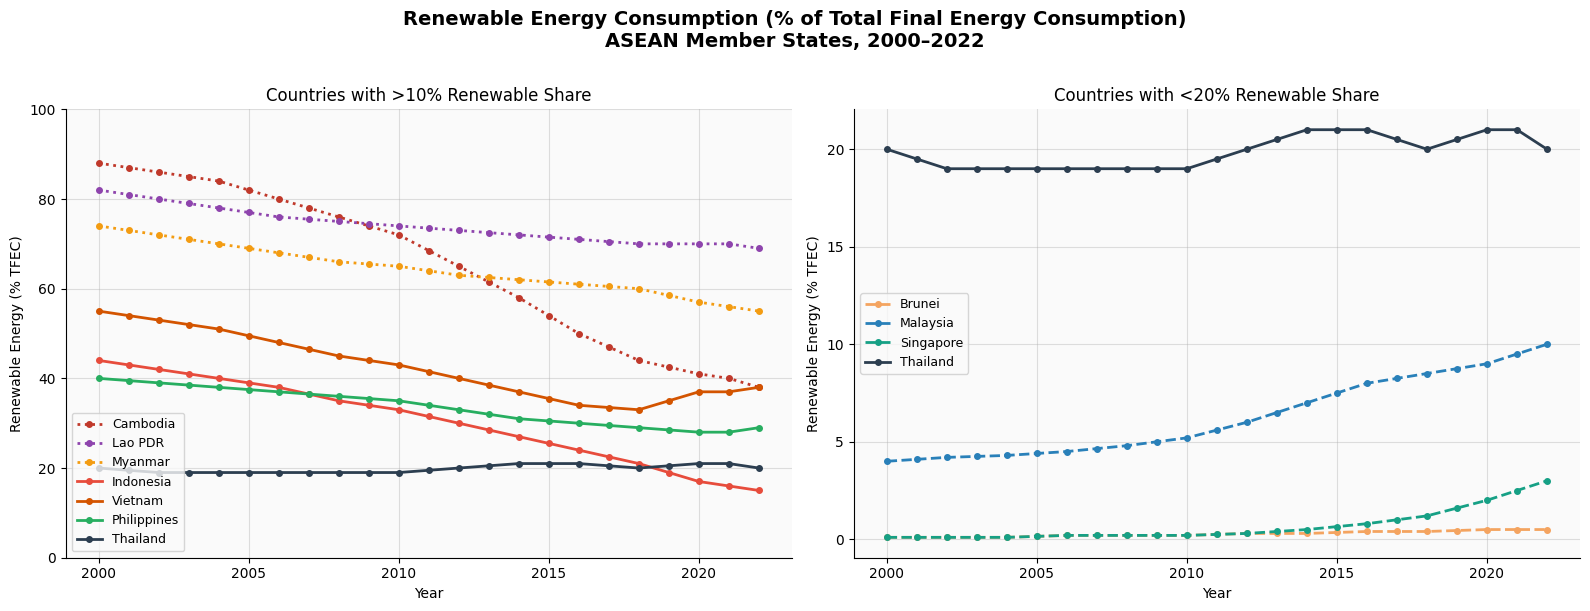

Figure saved ✓


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Renewable Energy Consumption (% of Total Final Energy Consumption)\nASEAN Member States, 2000–2022',
             fontsize=14, fontweight='bold', y=1.01)

# Left: higher-renewable countries (>20%)
high = ['Cambodia', 'Lao PDR', 'Myanmar', 'Indonesia', 'Vietnam', 'Philippines', 'Thailand']
ax = axes[0]
for c in high:
    ls = REGION_STYLE[region_map[c]]
    ax.plot(YEARS, RENEWABLES[c], color=PALETTE[c], lw=2, ls=ls, marker='o', ms=4, label=c)
ax.set_title('Countries with >10% Renewable Share', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Renewable Energy (% TFEC)')
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0, 100)

# Right: lower-renewable countries (<20%)
low = ['Brunei', 'Malaysia', 'Singapore', 'Thailand']
ax2 = axes[1]
for c in low:
    ls = REGION_STYLE[region_map[c]]
    ax2.plot(YEARS, RENEWABLES[c], color=PALETTE[c], lw=2, ls=ls, marker='o', ms=4, label=c)
ax2.set_title('Countries with <20% Renewable Share', fontsize=12)
ax2.set_xlabel('Year'); ax2.set_ylabel('Renewable Energy (% TFEC)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_renewables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved ✓")

### Key Findings — Renewable Energy

**The "falling floor" problem:** Indonesia, Cambodia, Vietnam, and the Philippines have all seen their renewable share *decline* significantly since 2000. This is not because they adopted less renewable energy in absolute terms — it is because coal-fired power expansion outpaced renewables growth. Indonesia's renewable share fell from ~44% to ~15% over two decades, driven by coal's dominance in its electricity mix.

**Vietnam's solar inflection:** Vietnam shows a reversal after 2018, recovering its renewable share as a rapid feed-in tariff programme triggered a solar and wind boom. This policy-induced inflection point is a case study in how price mechanisms can rapidly shift trajectory.

**The biomass caveat:** Lao PDR, Cambodia, and Myanmar show high renewable shares primarily due to traditional biomass use — cooking on wood and charcoal. This is a development gap indicator, not a clean energy achievement. Distinguishing modern renewables (solar, wind, hydro) from traditional biomass is critical for policy design.

**Regional implication:** ASEAN as a bloc cannot claim a renewable transition simply by referencing headline numbers. Policymakers must disaggregate by energy end-use, income level, and energy type.


## 4. CO₂ Emissions Per Capita (2000–2022)

CO₂ emissions per capita measure each country's carbon intensity per person, controlling for population size. This indicator reveals structural differences in energy systems and economic activity levels, and is a core metric in climate policy negotiations.


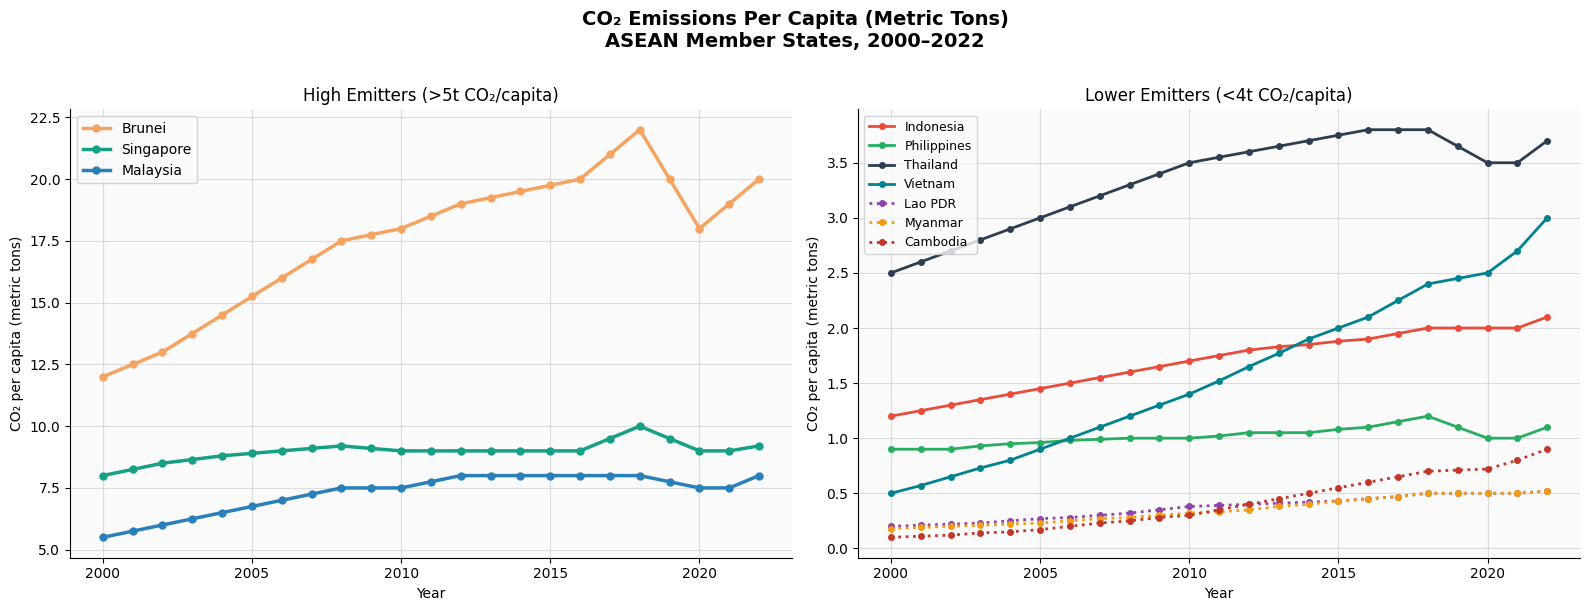

Figure saved ✓


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CO₂ Emissions Per Capita (Metric Tons)\nASEAN Member States, 2000–2022',
             fontsize=14, fontweight='bold', y=1.01)

local_palette = {**PALETTE, 'Vietnam': '#00838F'}

# Left: high emitters
high_emit = ['Brunei', 'Singapore', 'Malaysia']
ax = axes[0]
for c in high_emit:
    ax.plot(YEARS, CO2_PC[c], color=local_palette[c], lw=2.5, marker='o', ms=5, label=c)
ax.set_title('High Emitters (>5t CO₂/capita)', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('CO₂ per capita (metric tons)')
ax.legend(fontsize=10)

# Right: lower emitters
low_emit = ['Indonesia','Philippines','Thailand','Vietnam','Lao PDR','Myanmar','Cambodia']
ax2 = axes[1]
for c in low_emit:
    ls = REGION_STYLE[region_map[c]]
    ax2.plot(YEARS, CO2_PC[c], color=local_palette[c], lw=2, ls=ls, marker='o', ms=4, label=c)
ax2.set_title('Lower Emitters (<4t CO₂/capita)', fontsize=12)
ax2.set_xlabel('Year'); ax2.set_ylabel('CO₂ per capita (metric tons)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_co2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved ✓")

### Key Findings — CO₂ Emissions

**Convergence from below:** Lower-income ASEAN economies (Vietnam, Cambodia, Lao PDR, Indonesia) are all on upward CO₂ trajectories as industrialisation accelerates. Vietnam's per-capita emissions grew 6× between 2000 and 2022, reflecting rapid manufacturing-led growth heavily reliant on coal power.

**Flat or declining at the top:** Singapore and Malaysia show stable or slightly declining emissions per capita since ~2010, suggesting some decoupling from GDP growth at higher income levels.

**Brunei's structural challenge:** Brunei presents a distinct profile — an oil-producing state with among the highest per-capita emissions in Southeast Asia, driven by energy subsidies and a fossil-fuel-dependent economy with limited diversification pressure.

**Policy tension:** The emerging ASEAN economies that most need economic growth are also those whose emissions are rising fastest. This creates a central tension for regional climate frameworks: how to support development pathways that do not lock in high-carbon infrastructure.


## 5. Electricity Access (% of Population), 2000–2022

Universal electricity access is a precondition for economic development and is directly tracked under UN Sustainable Development Goal 7 (SDG 7). ASEAN has made remarkable collective progress, but significant gaps remain.


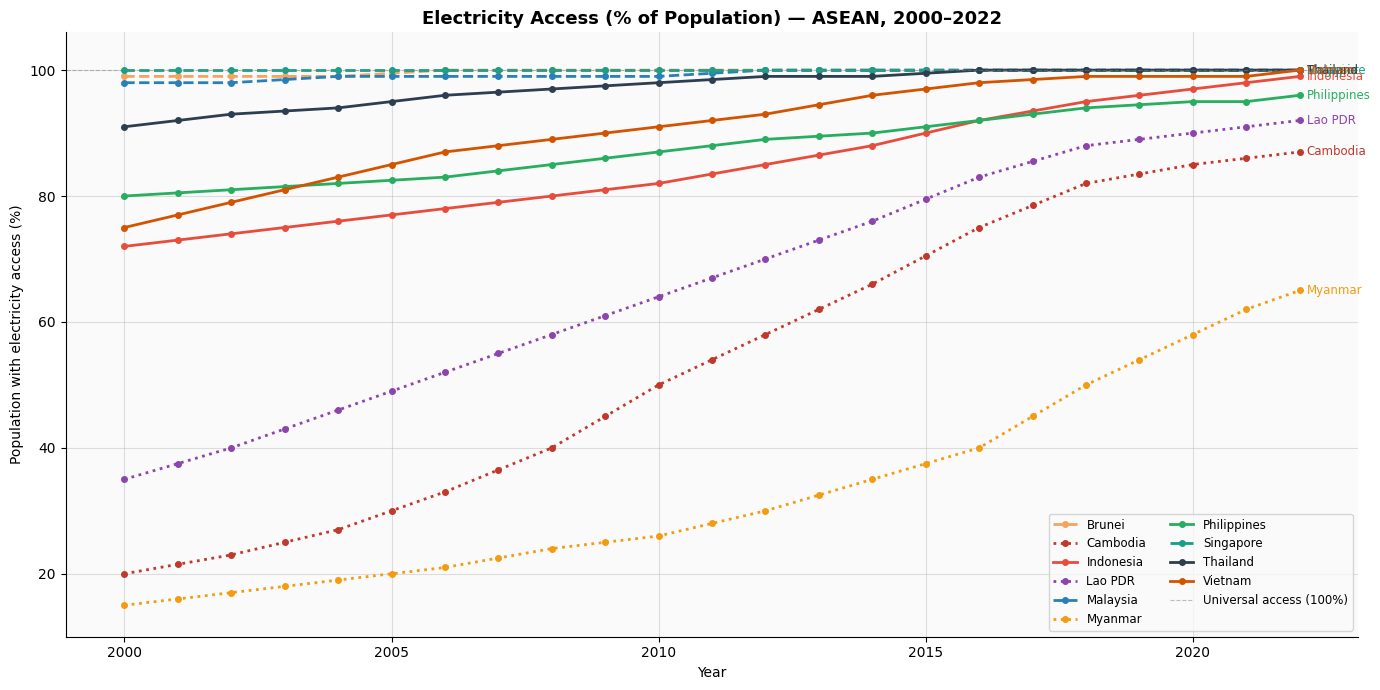

Figure saved ✓


In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

local_palette = {**PALETTE, 'Vietnam': '#00838F'}

for c, vals in ELEC_ACCESS.items():
    ls = REGION_STYLE[region_map[c]]
    ax.plot(YEARS, vals, color=PALETTE[c], lw=2, ls=ls, marker='o', ms=4, label=c)
    # Label endpoint
    ax.annotate(c, xy=(2022, vals[-1]), xytext=(5, 0),
                textcoords='offset points', fontsize=8.5, color=PALETTE[c], va='center')

ax.axhline(y=100, color='gray', lw=0.8, ls='--', alpha=0.5, label='Universal access (100%)')
ax.set_title('Electricity Access (% of Population) — ASEAN, 2000–2022',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Population with electricity access (%)')
ax.set_ylim(10, 106)
ax.legend(fontsize=8.5, loc='lower right', ncol=2)

plt.tight_layout()
plt.savefig('fig_access.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved ✓")

### Key Findings — Electricity Access

**Dramatic progress:** Between 2000 and 2022, Cambodia raised its electrification rate from ~20% to ~87%, Lao PDR from ~35% to ~92%, and Indonesia from ~72% to ~99%. These are among the most significant energy access expansions in the developing world.

**Myanmar remains the critical gap:** Despite some progress, Myanmar stands at ~65% electrification — the lowest in ASEAN by a significant margin. Political instability since 2021 has reversed earlier gains in energy infrastructure investment, making this a policy priority that intersects energy and governance concerns.

**Universal access as a convergence point:** Brunei, Malaysia, Singapore, Thailand, and Vietnam have achieved or are approaching 100% access. The remaining challenge is concentrated in Myanmar and, to a lesser extent, Cambodia and the Philippines in rural and island areas.

**ASEAN implications:** The continued electrification gap within ASEAN is a development inequality issue as much as an energy issue. It affects industrial competitiveness, health outcomes, and educational attainment.


## 6. GDP per Capita vs CO₂ Emissions

This section examines the GDP per Capita vs CO2 Emissions in ASEAN countries.


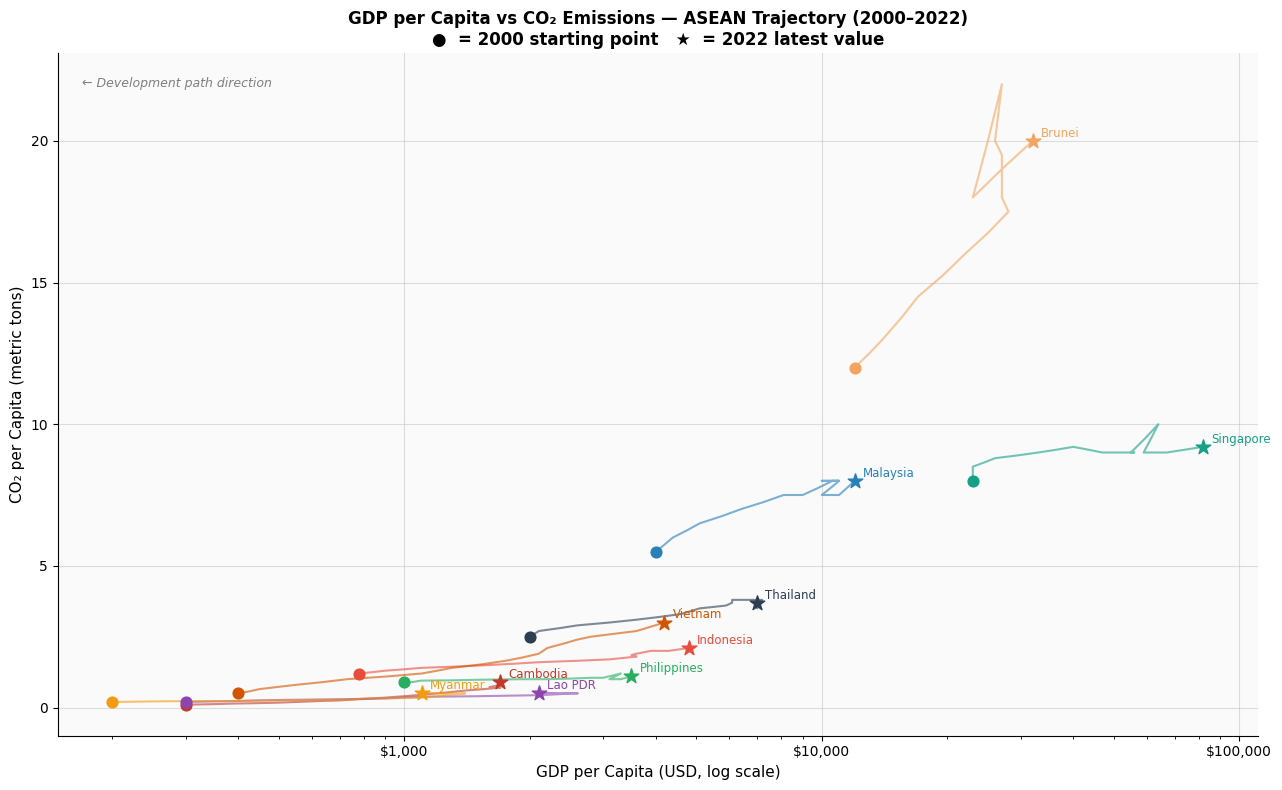

Figure saved ✓


In [19]:
fig, ax = plt.subplots(figsize=(13, 8))

for c in COUNTRIES:
    x = GDP_PC[c]
    y = CO2_PC[c]
    ax.plot(x, y, color=PALETTE[c], lw=1.5, alpha=0.6)
    # Mark 2000 and 2022 endpoints
    ax.scatter(x[0],  y[0],  color=PALETTE[c], marker='o', s=60, zorder=5)
    ax.scatter(x[-1], y[-1], color=PALETTE[c], marker='*', s=120, zorder=5)
    ax.annotate(c, xy=(x[-1], y[-1]), xytext=(6, 3),
                textcoords='offset points', fontsize=8.5, color=PALETTE[c])

ax.set_xscale('log')
ax.set_xlabel('GDP per Capita (USD, log scale)', fontsize=11)
ax.set_ylabel('CO₂ per Capita (metric tons)', fontsize=11)
ax.set_title('GDP per Capita vs CO₂ Emissions — ASEAN Trajectory (2000–2022)\n'
             '●  = 2000 starting point   ★  = 2022 latest value',
             fontsize=12, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax.annotate('← Development path direction', xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('fig_kuznets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved ✓")

### Key Findings

**Rising emissions-income coupling for developing economies:** Cambodia, Lao PDR, Myanmar, Vietnam, and Indonesia all trace upward-right trajectories — increasing both income and emissions simultaneously. This is expected at early-to-middle development stages.

**Possible early peak for Malaysia:** Malaysia's trajectory suggests emissions per capita are stabilising (around 7.5–8 metric tons) despite continued GDP growth, hinting at an early decoupling dynamic. This may reflect efficiency improvements and some renewable capacity expansion.

**Singapore's plateau:** Singapore shows a flat or very slightly declining CO₂ per capita at high income levels, likely supported by gas-to-renewables policy shifts and a services-dominant economy.

**Policy implication — the critical window:** Vietnam and Indonesia are approaching the stage where infrastructure lock-in decisions will be made. If new power plants and industrial facilities are built as coal or gas infrastructure (typically with 30–40 year lifespans), these countries will lock in high emissions trajectories well past 2050. Directing renewable investment is significantly more cost-effective and climatically meaningful.


## 7. Composite Ranking — Energy Transition Readiness

To synthesise the four indicators, we construct a simple normalised composite score ranking each ASEAN country on: (1) current renewable share, (2) CO₂ per capita (inverted), (3) electricity access, and (4) change in renewable share 2000–2022.

This is illustrative — not a definitive index — but provides a useful summary view for policy discussion.


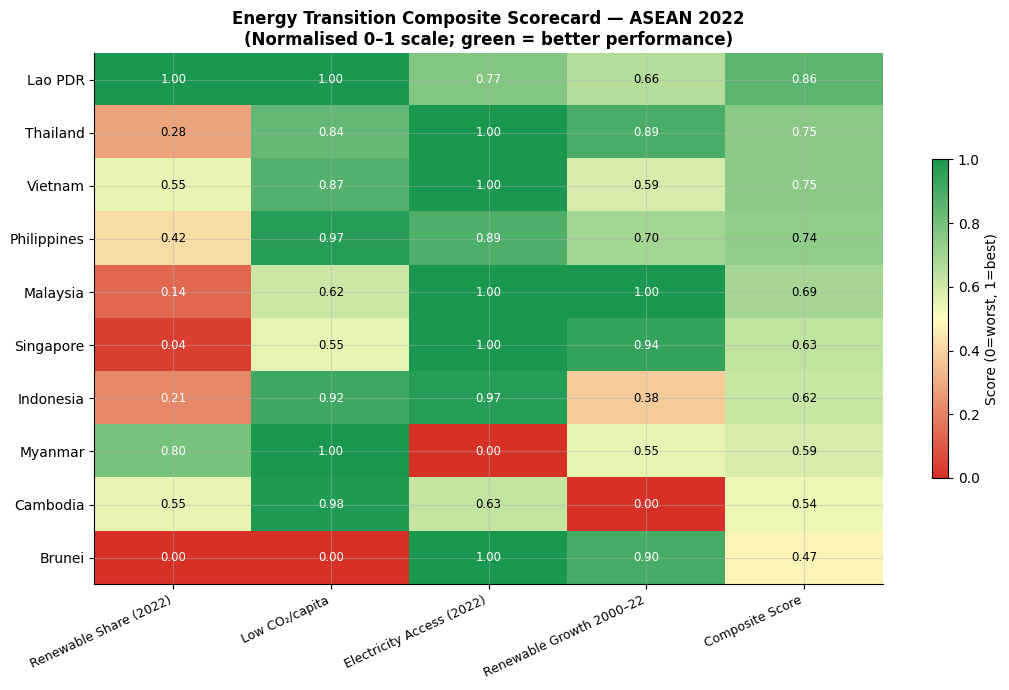


── Composite Ranking ──
             Composite Score
Lao PDR                0.858
Thailand               0.754
Vietnam                0.752
Philippines            0.742
Malaysia               0.689
Singapore              0.634
Indonesia              0.619
Myanmar                0.587
Cambodia               0.539
Brunei                 0.475


In [20]:
from matplotlib.colors import LinearSegmentedColormap

countries_list = list(COUNTRIES.keys())

renew_2022  = np.array([RENEWABLES[c][-1]   for c in countries_list])
co2_2022    = np.array([CO2_PC[c][-1]        for c in countries_list])
access_2022 = np.array([ELEC_ACCESS[c][-1]   for c in countries_list])
renew_chg   = renew_2022 - np.array([RENEWABLES[c][0] for c in countries_list])

def norm(arr, invert=False):
    mn, mx = arr.min(), arr.max()
    s = (arr - mn) / (mx - mn) if mx > mn else arr * 0 + 0.5
    return 1 - s if invert else s

scores = pd.DataFrame({
    'Renewable Share (2022)':      norm(renew_2022),
    'Low CO₂/capita':              norm(co2_2022, invert=True),
    'Electricity Access (2022)':   norm(access_2022),
    'Renewable Growth 2000–22':    norm(renew_chg),
}, index=countries_list)

scores['Composite Score'] = scores.mean(axis=1)
scores = scores.sort_values('Composite Score', ascending=False)

# ── Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
cols = ['Renewable Share (2022)','Low CO₂/capita','Electricity Access (2022)','Renewable Growth 2000–22','Composite Score']
cmap = LinearSegmentedColormap.from_list('eria', ['#d73027','#ffffbf','#1a9850'])
mat = scores[cols].values

im = ax.imshow(mat, cmap=cmap, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=25, ha='right', fontsize=9)
ax.set_yticks(range(len(scores))); ax.set_yticklabels(scores.index, fontsize=10)
ax.set_title('Energy Transition Composite Scorecard — ASEAN 2022\n'
             '(Normalised 0–1 scale; green = better performance)', fontsize=12, fontweight='bold')

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                fontsize=8.5, color='black' if 0.25 < mat[i,j] < 0.75 else 'white')

plt.colorbar(im, ax=ax, shrink=0.6, label='Score (0=worst, 1=best)')
plt.tight_layout()
plt.savefig('fig_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Composite Ranking ──")
print(scores[['Composite Score']].round(3).to_string())

## 8. Policy Implications & Conclusions

This analysis identifies four structural themes that should inform energy transition research agenda:

### 8.1 The "Coal Lock-in" Risk is the Central Policy Challenge
Indonesia and Vietnam — the two largest emerging ASEAN economies — are at inflection points where long-lived infrastructure decisions will determine their 2050 carbon trajectories. Further research can contribute by modelling alternative pathways (Just Energy Transition Partnerships, carbon pricing mechanisms) that allow continued growth without locking in coal.

### 8.2 Traditional Biomass Must Be Disaggregated from Modern Renewables
Regional renewable energy statistics overstate clean energy progress in lower-income ASEAN states. Need further action to advocate for, and adopt — disaggregated indicators that distinguish modern renewable energy (solar, wind, hydro, geothermal) from traditional biomass in all policy analyses.

### 8.3 Myanmar Requires Dedicated Attention
Myanmar is an outlier on multiple dimensions: energy access, CO₂ growth trajectory, and political risk. Energy policy in Myanmar cannot be separated from governance analysis.

### 8.4 Evidence of Decoupling at Higher Income Levels is Encouraging but Fragile
Malaysia and Singapore show signs of CO₂-income decoupling. Research should examine *which* specific policies, technologies, and structural shifts are driving this, with a view to identifying transferable lessons for Thailand, Philippines, and Vietnam — all approaching the middle-income transition zone.

---
### Data & Reproducibility Note
All data in this analysis are sourced from the World Bank World Development Indicators (WDI) database, retrieved April 2025. Indicator codes: `EG.FEC.RNEW.ZS`, `EN.ATM.CO2E.PC`, `EG.ELC.ACCS.ZS`, `NY.GDP.PCAP.CD`. The dataset covers 2000–2022 for all 10 ASEAN member states. Full replication code is available in this notebook.

